# Простая CNN с нуля + аугментация как расширение датасета

1. Берём `dataset/`, выкидываем точные дубликаты (`_context/duplicates.csv`), делим `Training` на train/val. `Testing` оставляем как test.
2. **Расширяем train аугментацией.** Каждый снимок train превращается в `EXPAND` разных вариантов, и они генерируются заново каждую эпоху. Это то же, что сохранить N× копий на диск, только без мусора на диске и с бо́льшим разнообразием. Val/test не аугментируются.
3. Обучаем небольшую свёрточную сеть **без предобучения**.
4. Считаем метрики: Precision / Recall / F1 по классам, матрицу ошибок, проверяем цель ≥ 85 %.

Сравнение уровней аугментации: меняйте `LEVEL` (`none` → `A` → `AB` → `ABC`) и перезапускайте. Итоги каждого запуска дописываются в `notebooks/results.csv`.

In [1]:
# ===== Настройки =====
LEVEL = "AB"      # none | A | AB | ABC  (см. augmentation/augment.py)
EXPAND = 3        # во сколько раз расширяем train аугментацией (для LEVEL="none" игнорируется)
EPOCHS = 20
BATCH = 64
LR = 1e-3
VAL_FRAC = 0.15   # доля Training, уходящая в валидацию
SEED = 42
NUM_WORKERS = 4   # процессы для аугментации; при ошибках DataLoader поставьте 0

In [2]:
import sys, time, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from tqdm.auto import tqdm

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "augmentation"))
from augment import load_image, build_transforms, CLASSES, IMG_SIZE
from dataset import MRIDataset

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("ROOT:", ROOT)
print("torch", torch.__version__, "| device:", DEVICE, torch.cuda.get_device_name(0) if DEVICE == "cuda" else "")

C:\Users\Janfik\Desktop\MRT x-ray\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ROOT: C:\Users\Janfik\Desktop\MRT x-ray
torch 2.11.0+cu128 | device: cuda NVIDIA GeForce RTX 5070 Ti


## 1. Данные: очистка дублей и split

In [3]:
dup = pd.read_csv(ROOT / "_context" / "duplicates.csv")
DROP = {(ROOT / p).resolve() for p in dup.loc[dup.keep == 0, "path"]}

def collect(split):
    rows = []
    for label, cls in enumerate(CLASSES):
        for p in sorted((ROOT / "dataset" / split / cls).glob("*.jpg")):
            if p.resolve() not in DROP:
                rows.append({"path": str(p), "label": label, "cls": cls})
    return pd.DataFrame(rows)

train_all, test_df = collect("Training"), collect("Testing")
train_df, val_df = train_test_split(train_all, test_size=VAL_FRAC, stratify=train_all.label, random_state=SEED)
train_df, val_df = train_df.reset_index(drop=True), val_df.reset_index(drop=True)

print(f"Удалено дублей: {len(DROP)}")
pd.DataFrame({
    "train": train_df.cls.value_counts(),
    "val": val_df.cls.value_counts(),
    "test": test_df.cls.value_counts(),
}).loc[list(CLASSES)].assign(**{"train после расширения": lambda d: d.train * (EXPAND if LEVEL != "none" else 1)})

Удалено дублей: 187


,train,val,test,train после расширения
cls,,,,
glioma,1190,210,386,3570
meningioma,1178,208,398,3534
notumor,1089,192,400,3267
pituitary,1157,205,400,3471


## 2. Предобработка (один раз, кэш в RAM)

grayscale → обрезка чёрных полей → вписать в 224×224. Одинаково для всех выборок. Результат кэшируется в `cache/`, повторный запуск займёт секунды.

In [4]:
CACHE = ROOT / "cache"; CACHE.mkdir(exist_ok=True)
prep = build_transforms("none")

def load_split(df, name):
    f = CACHE / f"{name}_{IMG_SIZE}.npz"
    paths = np.array(df.path.tolist(), dtype=str)
    if f.exists():
        z = np.load(f)
        if np.array_equal(z["paths"], paths):
            return z["x"]
    x = np.stack([prep(image=load_image(p))["image"] for p in tqdm(df.path, desc=name)])
    np.savez(f, x=x, paths=paths)
    return x

X_train, X_val, X_test = (load_split(d, n) for d, n in [(train_df, "train"), (val_df, "val"), (test_df, "test")])
y_train, y_val, y_test = (d.label.to_numpy() for d in (train_df, val_df, test_df))
print(X_train.shape, X_val.shape, X_test.shape, X_train.dtype)

(4614, 224, 224) (815, 224, 224) (1584, 224, 224) uint8


## 3. Расширение аугментацией

In [5]:
# MRIDataset лежит в augmentation/dataset.py (иначе num_workers > 0 не работает на Windows)
ds_train = MRIDataset(X_train, y_train, LEVEL, EXPAND)
ds_val, ds_test = MRIDataset(X_val, y_val), MRIDataset(X_test, y_test)
pin = DEVICE == "cuda"
dl_train = DataLoader(ds_train, BATCH, shuffle=True, num_workers=NUM_WORKERS, pin_memory=pin, drop_last=True,
                      persistent_workers=NUM_WORKERS > 0)
dl_val = DataLoader(ds_val, 256, pin_memory=pin)  # без аугментации — воркеры не нужны
dl_test = DataLoader(ds_test, 256, pin_memory=pin)
print(f"train: {len(X_train)} снимков -> {len(ds_train)} за эпоху (уровень {LEVEL}, x{ds_train.expand})")

train: 4614 снимков -> 13842 за эпоху (уровень AB, x3)


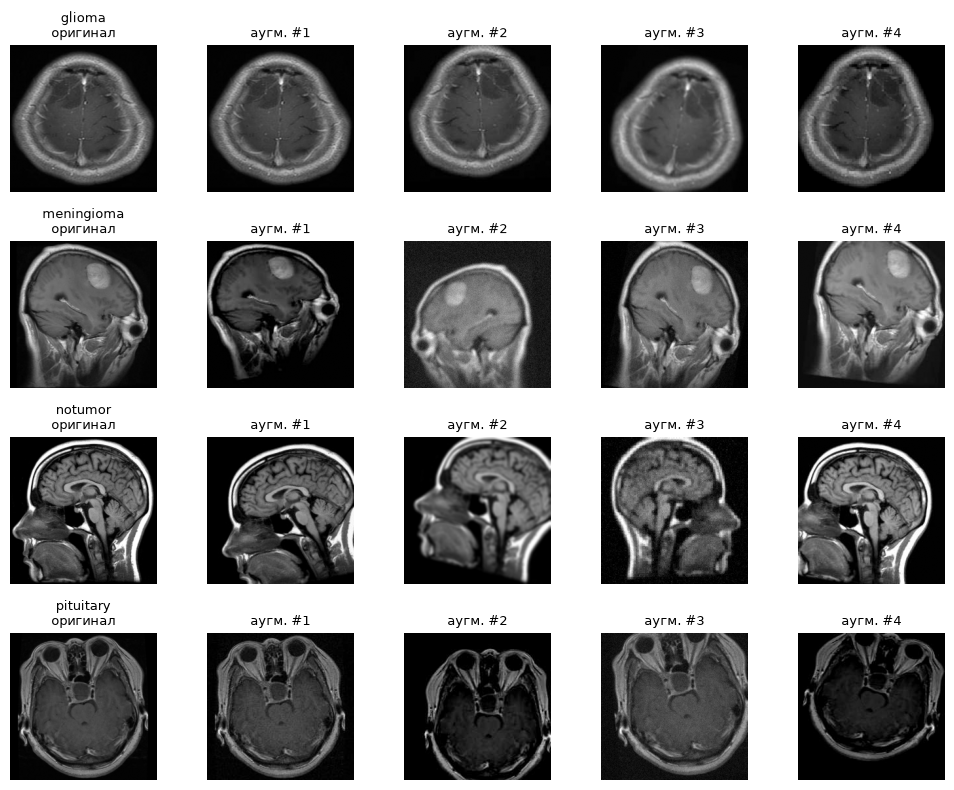

In [6]:
# Как выглядит расширенный набор: оригинал + EXPAND аугментированных вариантов по одному снимку на класс
n_show = max(EXPAND, 4)
tf_show = build_transforms(LEVEL if LEVEL != "none" else "AB")
fig, axes = plt.subplots(len(CLASSES), n_show + 1, figsize=(2 * (n_show + 1), 2 * len(CLASSES)))
for r, c in enumerate(CLASSES):
    img = X_train[np.flatnonzero(y_train == r)[0]]
    axes[r, 0].imshow(img, cmap="gray"); axes[r, 0].set_title(f"{c}\nоригинал", fontsize=9)
    for k in range(n_show):
        axes[r, k + 1].imshow(tf_show(image=img)["image"], cmap="gray"); axes[r, k + 1].set_title(f"аугм. #{k + 1}", fontsize=9)
for a in axes.ravel(): a.axis("off")
plt.tight_layout(); plt.show()

## 4. Простая CNN (без предобучения)

5 блоков `Conv3×3 → BatchNorm → ReLU → MaxPool`, каналы 16→32→64→128→256, затем Global Average Pooling → Dropout → Linear. Около 0.4 млн параметров.

In [7]:
def block(cin, cout):
    return nn.Sequential(nn.Conv2d(cin, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout),
                         nn.ReLU(inplace=True), nn.MaxPool2d(2))

class SimpleCNN(nn.Module):
    def __init__(self, n_classes=len(CLASSES), ch=(16, 32, 64, 128, 256), dropout=0.3):
        super().__init__()
        layers, cin = [], 1
        for c in ch:
            layers.append(block(cin, c)); cin = c
        self.features = nn.Sequential(*layers)
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(dropout), nn.Linear(cin, n_classes))

    def forward(self, x):
        return self.head(self.features(x))

model = SimpleCNN().to(DEVICE)
print(f"Параметров: {sum(p.numel() for p in model.parameters()):,}")

Параметров: 393,844


## 5. Обучение

In [8]:
@torch.no_grad()
def predict(loader):
    model.eval()
    ys, ps, loss = [], [], 0.0
    for x, y in loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE)
        with torch.autocast(DEVICE, enabled=DEVICE == "cuda"):
            out = model(x)
        loss += nn.functional.cross_entropy(out.float(), y, reduction="sum").item()
        ys.append(y.cpu()); ps.append(out.argmax(1).cpu())
    ys, ps = torch.cat(ys).numpy(), torch.cat(ps).numpy()
    return ys, ps, loss / len(ys)

opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=LR, total_steps=EPOCHS * len(dl_train))
scaler = torch.amp.GradScaler(enabled=DEVICE == "cuda")
crit = nn.CrossEntropyLoss()

hist, best_f1, best_state = [], -1, None
for ep in range(1, EPOCHS + 1):
    model.train(); t0 = time.time(); tl, tc, tn = 0.0, 0, 0
    for x, y in tqdm(dl_train, desc=f"epoch {ep}/{EPOCHS}", leave=False):
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE)
        with torch.autocast(DEVICE, enabled=DEVICE == "cuda"):
            out = model(x); loss = crit(out, y)
        opt.zero_grad(set_to_none=True)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
        tl += loss.item() * len(y); tc += (out.argmax(1) == y).sum().item(); tn += len(y)
    yv, pv, vl = predict(dl_val)
    _, rec, f1, _ = precision_recall_fscore_support(yv, pv, average="macro", zero_division=0)
    hist.append({"epoch": ep, "train_loss": tl / tn, "train_acc": tc / tn, "val_loss": vl,
                 "val_acc": (yv == pv).mean(), "val_recall": rec, "val_f1": f1})
    if f1 > best_f1:
        best_f1, best_state = f1, {k: v.detach().clone() for k, v in model.state_dict().items()}
    h = hist[-1]
    print(f"ep {ep:2d} | train loss {h['train_loss']:.3f} acc {h['train_acc']:.3f} | "
          f"val loss {vl:.3f} acc {h['val_acc']:.3f} macro-R {rec:.3f} F1 {f1:.3f} | {time.time() - t0:.0f}s")

model.load_state_dict(best_state)
hist = pd.DataFrame(hist)
print(f"Лучшая эпоха по val macro-F1: {int(hist.val_f1.idxmax()) + 1} (F1 = {best_f1:.3f})")

epoch 1/20:   0%|          | 0/216 [00:00<?, ?it/s]

epoch 1/20:   0%|          | 1/216 [00:13<47:26, 13.24s/it]

epoch 1/20:   3%|▎         | 6/216 [00:13<05:45,  1.65s/it]

epoch 1/20:   6%|▌         | 12/216 [00:13<02:16,  1.50it/s]

epoch 1/20:   8%|▊         | 18/216 [00:13<01:12,  2.72it/s]

...

epoch 20/20:  89%|████████▉ | 193/216 [00:03<00:00, 58.40it/s]

epoch 20/20:  92%|█████████▏| 199/216 [00:03<00:00, 58.41it/s]

epoch 20/20:  95%|█████████▍| 205/216 [00:03<00:00, 58.23it/s]

epoch 20/20:  98%|█████████▊| 211/216 [00:03<00:00, 58.25it/s]

ep 20 | train loss 0.163 acc 0.943 | val loss 0.116 acc 0.967 macro-R 0.967 F1 0.967 | 4s
Лучшая эпоха по val macro-F1: 20 (F1 = 0.967)


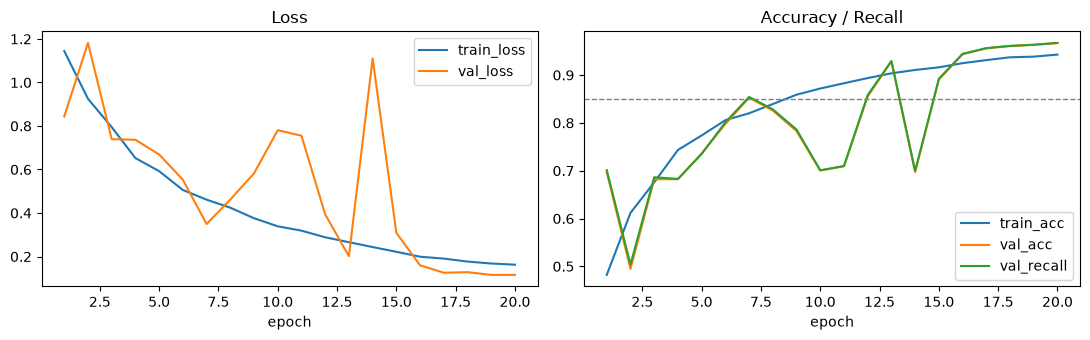

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
hist.plot(x="epoch", y=["train_loss", "val_loss"], ax=ax[0], title="Loss")
hist.plot(x="epoch", y=["train_acc", "val_acc", "val_recall"], ax=ax[1], title="Accuracy / Recall")
ax[1].axhline(0.85, ls="--", c="gray", lw=1)
plt.tight_layout(); plt.show()

## 6. Метрики на test

In [10]:
yt, pt, _ = predict(dl_test)
print(classification_report(yt, pt, target_names=CLASSES, digits=3))

P, R, F, S = precision_recall_fscore_support(yt, pt, zero_division=0)
ok = lambda v: "✅" if v >= 0.85 else "❌"
summary = pd.DataFrame({"Precision": P, "Recall": R, "F1": F, "N": S}, index=CLASSES)
summary["цель ≥ 85%"] = [ok(min(p, r)) for p, r in zip(P, R)]
summary.style.format({"Precision": "{:.3f}", "Recall": "{:.3f}", "F1": "{:.3f}"})

              precision    recall  f1-score   support

      glioma      0.981     0.798     0.880       386
  meningioma      0.885     0.930     0.907       398
     notumor      0.915     0.998     0.955       400
   pituitary      0.952     0.990     0.971       400

    accuracy                          0.930      1584
   macro avg      0.933     0.929     0.928      1584
weighted avg      0.933     0.930     0.928      1584



,Precision,Recall,F1,N,цель ≥ 85%
glioma,0.981,0.798,0.880,386,❌
meningioma,0.885,0.930,0.907,398,✅
notumor,0.915,0.998,0.955,400,✅
pituitary,0.952,0.990,0.971,400,✅


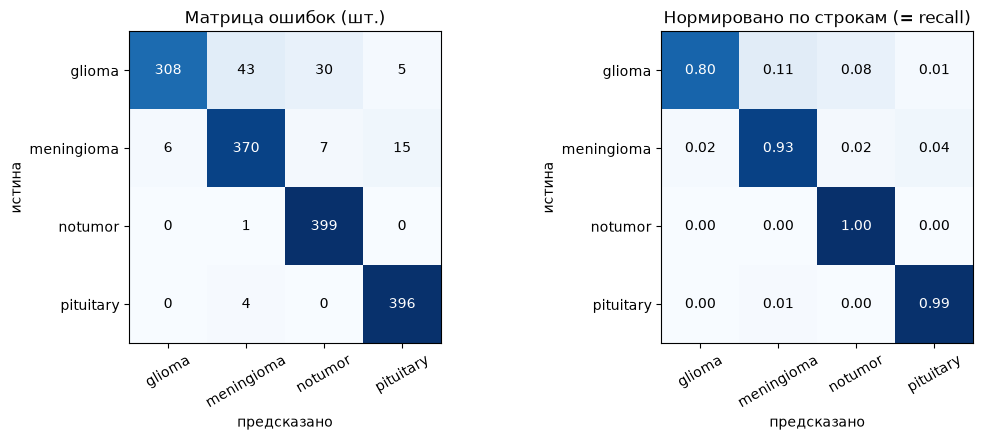

In [11]:
cm = confusion_matrix(yt, pt)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for a, m, title, fmt in [(ax[0], cm, "Матрица ошибок (шт.)", "d"),
                         (ax[1], cm / cm.sum(1, keepdims=True), "Нормировано по строкам (= recall)", ".2f")]:
    a.imshow(m, cmap="Blues")
    a.set_xticks(range(len(CLASSES)), CLASSES, rotation=30); a.set_yticks(range(len(CLASSES)), CLASSES)
    a.set_xlabel("предсказано"); a.set_ylabel("истина"); a.set_title(title)
    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            a.text(j, i, format(m[i, j], fmt), ha="center", va="center",
                   color="white" if m[i, j] > m.max() / 2 else "black")
plt.tight_layout(); plt.show()

## 7. Сохранение модели и итогов запуска

In [12]:
(ROOT / "notebooks" / "checkpoints").mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), ROOT / "notebooks" / "checkpoints" / f"simple_cnn_{LEVEL}_x{ds_train.expand}.pt")

mP, mR, mF, _ = precision_recall_fscore_support(yt, pt, average="macro", zero_division=0)
row = {"time": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"), "level": LEVEL, "expand": ds_train.expand,
       "epochs": EPOCHS, "seed": SEED, "test_acc": round((yt == pt).mean(), 4),
       "macro_P": round(mP, 4), "macro_R": round(mR, 4), "macro_F1": round(mF, 4),
       **{f"R_{c}": round(r, 4) for c, r in zip(CLASSES, R)},
       **{f"P_{c}": round(p, 4) for c, p in zip(CLASSES, P)}}
res_file = ROOT / "notebooks" / "results.csv"
res = pd.concat([pd.read_csv(res_file), pd.DataFrame([row])]) if res_file.exists() else pd.DataFrame([row])
res.to_csv(res_file, index=False)
res

,time,level,expand,epochs,seed,test_acc,macro_P,macro_R,macro_F1,R_glioma,R_meningioma,R_notumor,R_pituitary,P_glioma,P_meningioma,P_notumor,P_pituitary
0,2026-09-30 20:56,none,1,20,42,0.9211,0.9291,0.9195,0.9182,0.7409,0.9497,1.0000,0.9875,0.9965,0.8381,0.9112,0.9705
0,2026-09-30 20:58,AB,3,20,42,0.9299,0.9333,0.9288,0.9280,0.7979,0.9296,0.9975,0.9900,0.9809,0.8852,0.9151,0.9519
